In [1]:
import os.path
from pathlib import Path
import torch
import pandas as pd
import matplotlib.pyplot as plt
import psutil

from phi_3_5_constants import hidden_state_size, num_layers, dsets_folder

In [2]:
source_path = Path("D:\\TruthIsUniversal_In_Phi_3_5_Mini\\all_layers_activations_for_final_token_of_sequences")

In [3]:
real_world_categ = "real_world_scenarios"

In [4]:
dsets_index_df = pd.read_csv(dsets_folder / "categ_dataset_pairs.csv", index_col="Idx")

In [6]:
num_dsets = dsets_index_df.shape[0]

In [6]:
between_vs_within_class_var_ratios = torch.zeros((num_layers, num_dsets))

In [18]:
idxs_of_real_world_scenarios_dsets: dict[str, int] = {}

In [20]:
for dset_idx, row in dsets_index_df.iterrows():
    categ_nm = row["Categ_Folder"]
    dset_file_nm = row["Dataset_File"]
    dset_nm = os.path.splitext(dset_file_nm)[0]
    if categ_nm == real_world_categ:
        idxs_of_real_world_scenarios_dsets[dset_nm] = dset_idx
        continue
    print(f"starting {categ_nm} - {dset_nm}; memory situation: {psutil.virtual_memory()}")
    harvest_result_path = source_path / categ_nm / (dset_nm + ".pt")
    
    dataset = pd.read_csv(dsets_folder / categ_nm / dset_file_nm)
    labels = dataset['label'].to_numpy()
    del dataset
    
    activations_harvest_result = torch.load(harvest_result_path, weights_only=True)
    activations = activations_harvest_result['last_tok_hidden_states']
    # should be: num_layers by dataset_size by hidden_state_size
    dset_size = activations.shape[1]
    assert len(labels) == dset_size
    
    if categ_nm == "true_false":
        print(f"loaded hidden states; memory situation: {psutil.virtual_memory()}")
    
    activations_mean_overall = torch.mean(activations, dim=1)
    assert activations_mean_overall.shape == (num_layers, hidden_state_size)
    
    if categ_nm == "true_false":
        print(f"determined mean hidden state; memory situation: {psutil.virtual_memory()}")
    
    activations_on_true = activations[:, labels == 1, :]
    num_true_in_dset = activations_on_true.shape[1]
    assert num_true_in_dset > 0, f"{dset_nm} no true entries"
    activations_on_false = activations[:, labels == 0, :]
    num_false_in_dset = activations_on_false.shape[1]
    assert num_false_in_dset > 0, f"{dset_nm} no false entries"
    del activations
    del activations_harvest_result
    del labels
    if categ_nm == "true_false":
        print(f"separated out hidden states for true vs false statements; memory situation: {psutil.virtual_memory()}")
    
    activations_var_within_true, activations_mean_on_true = torch.var_mean(activations_on_true, dim=1)
    assert activations_var_within_true.shape == (num_layers, hidden_state_size)
    del activations_on_true
    activations_var_within_false, activations_mean_on_false = torch.var_mean(activations_on_false, dim=1)
    assert activations_mean_on_false.shape == (num_layers, hidden_state_size)
    del activations_on_false
    
    if categ_nm == "true_false":
        print(f"calculated within-class mean/variance for true and false statement sets separately; memory situation: {psutil.virtual_memory()}")
    
    avg_within_class_var = ((activations_var_within_true + activations_var_within_false)/2).mean(dim=1)
    assert avg_within_class_var.shape == (num_layers,)
    
    if categ_nm == "true_false":
        print(f"computed average within-class variance; memory situation: {psutil.virtual_memory()}")
    
    avg_btn_class_var = ((1 / dset_size) * ( num_true_in_dset*torch.square(activations_mean_on_true - activations_mean_overall)
                                            + num_false_in_dset*torch.square(activations_mean_on_false - activations_mean_overall))
                         ).mean(dim=1)
    assert avg_btn_class_var.shape == (num_layers,)
    
    if categ_nm == "true_false":
        print(f"computed between-class variance; memory situation: {psutil.virtual_memory()}")
    
    between_vs_within_class_var_ratios[:, dset_idx] = avg_btn_class_var / avg_within_class_var
    

starting animal_class - animal_class; memory situation: svmem(total=17019686912, available=3749199872, percent=78.0, used=13270487040, free=3749199872)
starting animal_class - animal_class_conj; memory situation: svmem(total=17019686912, available=9063354368, percent=46.7, used=7956332544, free=9063354368)
starting animal_class - animal_class_disj; memory situation: svmem(total=17019686912, available=9194614784, percent=46.0, used=7825072128, free=9194614784)
starting animal_class - neg_animal_class; memory situation: svmem(total=17019686912, available=9168113664, percent=46.1, used=7851573248, free=9168113664)
starting cities - cities; memory situation: svmem(total=17019686912, available=9227599872, percent=45.8, used=7792087040, free=9227599872)
starting cities - cities_conj; memory situation: svmem(total=17019686912, available=9521876992, percent=44.1, used=7497809920, free=9521876992)
starting cities - cities_disj; memory situation: svmem(total=17019686912, available=10176225280, p

In [22]:

real_world_activations_path = source_path / real_world_categ

ambig_false_harvest = torch.load(real_world_activations_path / "ambiguous_lie.pt", weights_only=True)
ambig_false_activs = ambig_false_harvest['last_tok_hidden_states']
ambig_true_harvest = torch.load(real_world_activations_path / "ambiguous_truthful_reply.pt", weights_only=True)
ambig_true_activs = ambig_true_harvest['last_tok_hidden_states']
num_ambig_false, num_ambig_true = ambig_false_activs.shape[1], ambig_true_activs.shape[1]
num_ambig = num_ambig_true + num_ambig_false

ambig_activs_mean_overall = torch.concat((ambig_false_activs, ambig_true_activs), dim=1).mean(dim=1)
assert ambig_activs_mean_overall.shape == (num_layers, hidden_state_size)

ambig_activs_var_within_true, ambig_activs_mean_on_true = torch.var_mean(ambig_true_activs, dim=1)
assert ambig_activs_var_within_true.shape == (num_layers, hidden_state_size)
ambig_activs_var_within_false, ambig_activs_mean_on_false = torch.var_mean(ambig_false_activs, dim=1)
assert ambig_activs_mean_on_false.shape == (num_layers, hidden_state_size)

ambig_avg_within_class_var = ((ambig_activs_var_within_true + ambig_activs_var_within_false)/2).mean(dim=1)
assert ambig_avg_within_class_var.shape == (num_layers,)

ambig_avg_btn_class_var = ((1 / num_ambig) * ( num_ambig_true*torch.square(ambig_activs_mean_on_true - ambig_activs_mean_overall)
                                         + num_ambig_false*torch.square(ambig_activs_mean_on_false - ambig_activs_mean_overall))
                     ).mean(dim=1)
assert ambig_avg_btn_class_var.shape == (num_layers,)

col_idx_for_ambig_sep = idxs_of_real_world_scenarios_dsets['ambiguous_lie']
between_vs_within_class_var_ratios[:, col_idx_for_ambig_sep] = ambig_avg_btn_class_var / ambig_avg_within_class_var

#TODO grab unambiguous-false activations 
#TODO grab unambiguous-true activations 
#TODO calc mean for unambiguous
#TODO calc within-class-var for unambiguous
#TODO calc btn-class-var for unambiguous
#TODO store unambiguous sep ratio in column for unambiguous lie

unambig_false_harvest = torch.load(real_world_activations_path / "unambiguous_lie.pt", weights_only=True)
unambig_false_activs = unambig_false_harvest['last_tok_hidden_states']
unambig_true_harvest = torch.load(real_world_activations_path / "unambiguous_truthful_reply.pt", weights_only=True)
unambig_true_activs = unambig_true_harvest['last_tok_hidden_states']
num_unambig_false, num_unambig_true = unambig_false_activs.shape[1], unambig_true_activs.shape[1]
num_unambig = num_unambig_true + num_unambig_false

unambig_activs_mean_overall = torch.concat((unambig_false_activs, unambig_true_activs), dim=1).mean(dim=1)
assert unambig_activs_mean_overall.shape == (num_layers, hidden_state_size)

unambig_activs_var_within_true, unambig_activs_mean_on_true = torch.var_mean(unambig_true_activs, dim=1)
assert unambig_activs_var_within_true.shape == (num_layers, hidden_state_size)
unambig_activs_var_within_false, unambig_activs_mean_on_false = torch.var_mean(unambig_false_activs, dim=1)
assert unambig_activs_mean_on_false.shape == (num_layers, hidden_state_size)

unambig_avg_within_class_var = ((unambig_activs_var_within_true + unambig_activs_var_within_false)/2).mean(dim=1)
assert unambig_avg_within_class_var.shape == (num_layers,)

unambig_avg_btn_class_var = ((1 / num_unambig) * ( num_unambig_true*torch.square(unambig_activs_mean_on_true - unambig_activs_mean_overall)
                                               + num_unambig_false*torch.square(unambig_activs_mean_on_false - unambig_activs_mean_overall))
                           ).mean(dim=1)
assert unambig_avg_btn_class_var.shape == (num_layers,)

col_idx_for_unambig_sep = idxs_of_real_world_scenarios_dsets['unambiguous_lie']
between_vs_within_class_var_ratios[:, col_idx_for_unambig_sep] = unambig_avg_btn_class_var / unambig_avg_within_class_var
between_vs_within_class_var_ratios

In [31]:
(between_vs_within_class_var_ratios := between_vs_within_class_var_ratios.nan_to_num(nan=0))

tensor([[0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00, 1.0484e-03,
         0.0000e+00],
        [4.4424e-02, 4.5249e-02, 8.4025e-04,  ..., 8.6991e-04, 3.4690e-03,
         9.3843e-05],
        [6.3832e-02, 5.4997e-02, 6.2673e-04,  ..., 8.2274e-04, 2.1706e-03,
         8.5110e-05],
        ...,
        [4.5008e-01, 3.0006e-01, 2.9343e-02,  ..., 4.3722e-02, 8.8401e-03,
         4.7543e-03],
        [4.6046e-01, 2.8420e-01, 3.0568e-02,  ..., 4.0024e-02, 8.3646e-03,
         4.5724e-03],
        [3.8262e-01, 2.4514e-01, 2.6546e-02,  ..., 4.3094e-02, 9.0547e-03,
         4.6032e-03]])

In [51]:
#the column for ambiguous_truthful_reply, honest_reply_despite_incentive_to_lie, and unambiguous_truthful_reply are all 0's
(avg_t_f_sep_by_layer := between_vs_within_class_var_ratios.sum(dim=1) / (num_dsets-3))

tensor([0.0022, 0.0101, 0.0119, 0.0118, 0.0105, 0.0105, 0.0131, 0.0126, 0.0150,
        0.0199, 0.0440, 0.0591, 0.0855, 0.1226, 0.1587, 0.2349, 0.2655, 0.2878,
        0.3149, 0.2982, 0.2897, 0.2796, 0.2643, 0.2587, 0.2393, 0.2263, 0.2026,
        0.1872, 0.1760, 0.1614, 0.1552, 0.1451, 0.1317])

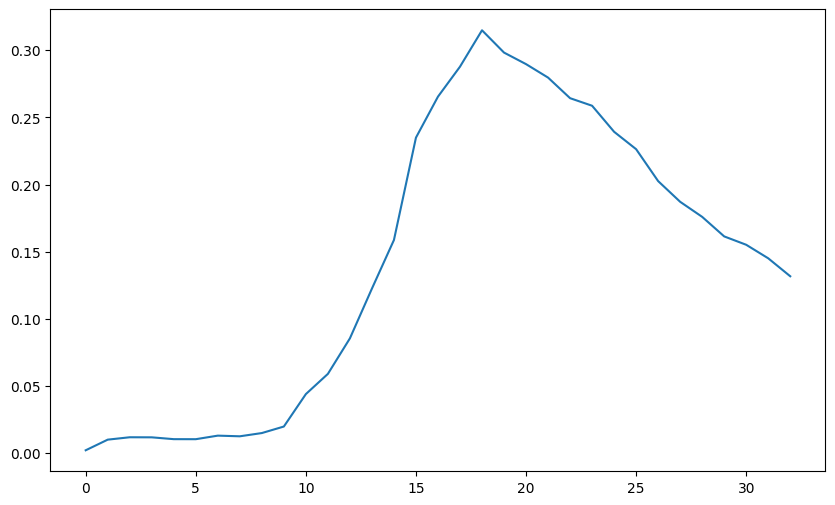

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))
avg_sep_by_layer_line_plot = ax.plot(range(num_layers), avg_t_f_sep_by_layer)
plt.show()

In [41]:
(best_layer_for_sep := avg_t_f_sep_by_layer.argmax().item())

18

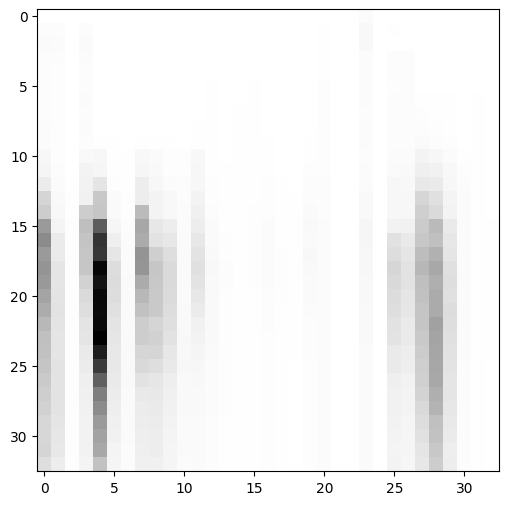

In [43]:
fig2, ax = plt.subplots(figsize=(10, 6))
all_sep_ratios_heatmap = ax.imshow(between_vs_within_class_var_ratios, cmap="Greys")
plt.show()

In [39]:
(max_sep_by_dataset := between_vs_within_class_var_ratios.max(dim=0))

torch.return_types.max(
values=tensor([0.9327, 0.3362, 0.0306, 0.6351, 1.7321, 0.4005, 0.0779, 0.8771, 0.5775,
        0.4255, 0.1019, 0.3652, 0.0932, 0.0356, 0.0179, 0.0313, 0.0599, 0.0245,
        0.0113, 0.0890, 0.0571, 0.0000, 0.0000, 0.1311, 0.0000, 0.4569, 0.3475,
        0.6792, 0.8028, 0.3861, 0.0569, 0.0169, 0.0126]),
indices=tensor([16, 21, 28, 15, 23, 19, 25, 17, 18, 18, 25, 18, 18, 18, 18, 17, 18, 18,
        16, 17, 16,  0,  0, 15,  0, 18, 18, 18, 22, 21, 19, 18, 18]))

In [50]:
separation_by_dataset = pd.DataFrame({
    "Category": dsets_index_df['Categ_Folder'],
    "Dataset": list(map(lambda x: os.path.splitext(x)[0], dsets_index_df['Dataset_File'])),
    "Max_Separation": max_sep_by_dataset.values.tolist(),
    "Best_Layer": max_sep_by_dataset.indices.tolist()
})
ambig_lie_idx = idxs_of_real_world_scenarios_dsets['ambiguous_lie']
unambig_lie_idx = idxs_of_real_world_scenarios_dsets['unambiguous_lie']
separation_by_dataset.at[ambig_lie_idx, "Dataset"] = "ambiguous_lies_truths"
separation_by_dataset.at[unambig_lie_idx, "Dataset"] = "unambiguous_lies_truths"
irrelevant_row_idxs = list(set(idxs_of_real_world_scenarios_dsets.values()) - {ambig_lie_idx, unambig_lie_idx})
separation_by_dataset = separation_by_dataset.drop(index=irrelevant_row_idxs)
separation_by_dataset

,Category,Dataset,Max_Separation,Best_Layer
Idx,,,,
0,animal_class,animal_class,0.932671,16
1,animal_class,animal_class_conj,0.336219,21
2,animal_class,animal_class_disj,0.030619,28
3,animal_class,neg_animal_class,0.635065,15
4,cities,cities,1.732109,23
5,cities,cities_conj,0.400464,19
6,cities,cities_disj,0.077865,25
7,cities,neg_cities,0.877118,17
8,element_symb,element_symb,0.577514,18


It seems clear that the hidden states after the 18th decoder block should be used for Phi 3.5 mini.
Meanwhile, it also seems worthwhile to test using the hidden states after the 25th decoder block - the average separation is still pretty high at that point and there are several datasets which reach their highest separation at or near that layer (including half of the disjunctive datasets).


It's interesting that, while this measure of separation did clearly show separation in the activations for many datasets (including the 4 that Bürger et al. used for this- "cities", "neg_cities", "sp_en_trans", & "neg_sp_en_trans"), it showed less separation for datasets of conjunctive statements (A and B) and _far_ less separation for datasets of disjunctive statements (A or B). It also shows shockingly low separation for some entire topics ("facts", "inventors", "true_false").

One heartening/confirmatory point is that it shows markedly more separation in the "unambiguous lies/truthful-replies" data than in the "ambiguous lies/truthful replies" data.

In [7]:
finalized_activations_dir = Path("D:\\TruthIsUniversal_In_Phi_3_5_Mini\\best2_layers_activations_for_final_token_of_sequences")

In [8]:
finalized_activations_dir.mkdir(exist_ok=True)

In [10]:
for dset_idx, row in dsets_index_df.iterrows():
    categ_nm = row["Categ_Folder"]
    dset_file_nm = row["Dataset_File"]
    dset_nm = os.path.splitext(dset_file_nm)[0]
    print(f"starting {categ_nm} - {dset_nm}; memory situation: {psutil.virtual_memory()}")
    harvest_result_path = source_path / categ_nm / (dset_nm + ".pt")
    
    dataset = pd.read_csv(dsets_folder / categ_nm / dset_file_nm)
    labels = dataset['label'].to_numpy()
    del dataset
    
    activations_harvest_result = torch.load(harvest_result_path, weights_only=True)
    activations = activations_harvest_result['last_tok_hidden_states']
    # should be: num_layers by dataset_size by hidden_state_size
    
    #i.e. just the activations _after_ the 18th and 25th decoder blocks 
    best2_layers_activations = activations[[18,25], :, :]
    
    categ_dir = finalized_activations_dir / categ_nm
    categ_dir.mkdir(exist_ok=True)
    
    torch.save(best2_layers_activations, categ_dir / (dset_nm + ".pt"))
    

starting animal_class - animal_class; memory situation: svmem(total=17019686912, available=4859019264, percent=71.5, used=12160667648, free=4859019264)
starting animal_class - animal_class_conj; memory situation: svmem(total=17019686912, available=4802830336, percent=71.8, used=12216856576, free=4802830336)
starting animal_class - animal_class_disj; memory situation: svmem(total=17019686912, available=4684738560, percent=72.5, used=12334948352, free=4684738560)
starting animal_class - neg_animal_class; memory situation: svmem(total=17019686912, available=4678533120, percent=72.5, used=12341153792, free=4678533120)
starting cities - cities; memory situation: svmem(total=17019686912, available=4813410304, percent=71.7, used=12206276608, free=4813410304)
starting cities - cities_conj; memory situation: svmem(total=17019686912, available=4263682048, percent=74.9, used=12756004864, free=4263682048)
starting cities - cities_disj; memory situation: svmem(total=17019686912, available=420738662